# Lab 4: Regression Analysis with Regularization Techniques

Name: Ashish Mahajan  
Course: 2026 Summer - Advanced Big Data and Data Mining (MSCS-634-M20)  
Dataset: Diabetes Dataset from sklearn

## Introduction
Regression predicts a continuous numeric target. In this lab, the Diabetes dataset contains health-related measurements used to predict a continuous disease progression value.

The models compared in this notebook are:
- Simple Linear Regression, which uses one feature.
- Multiple Linear Regression, which uses multiple features.
- Polynomial Regression, which creates nonlinear feature combinations.
- Ridge Regression, which uses L2 regularization to shrink coefficients.
- Lasso Regression, which uses L1 regularization and can shrink some coefficients to zero.

Overfitting happens when a model learns the training data too closely and performs poorly on unseen data. Underfitting happens when a model is too simple to capture useful patterns. Regularization helps control model complexity so the model can generalize better.


## Import Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

os.makedirs("screenshots", exist_ok=True)
pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True


## Helper Functions

In [2]:
def evaluate_model(model_name, y_train, train_predictions, y_test, test_predictions):
    return {
        "Model": model_name,
        "Train MAE": mean_absolute_error(y_train, train_predictions),
        "Test MAE": mean_absolute_error(y_test, test_predictions),
        "Train MSE": mean_squared_error(y_train, train_predictions),
        "Test MSE": mean_squared_error(y_test, test_predictions),
        "Train RMSE": root_mean_squared_error(y_train, train_predictions),
        "Test RMSE": root_mean_squared_error(y_test, test_predictions),
        "Train R2": r2_score(y_train, train_predictions),
        "Test R2": r2_score(y_test, test_predictions),
    }


def plot_actual_vs_predicted(y_test, predictions, title, file_path):
    plt.figure(figsize=(7, 5))
    plt.scatter(y_test, predictions, alpha=0.75, color="#2f6f9f", edgecolor="white", linewidth=0.6)
    min_value = min(y_test.min(), predictions.min())
    max_value = max(y_test.max(), predictions.max())
    plt.plot([min_value, max_value], [min_value, max_value], color="#c44e52", linestyle="--", label="Ideal prediction")
    plt.title(title)
    plt.xlabel("Actual Disease Progression")
    plt.ylabel("Predicted Disease Progression")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(file_path, dpi=150)
    plt.show()


## Step 1: Load and Prepare the Dataset

The Diabetes dataset is loaded directly from sklearn. The dataset has 442 samples, 10 numeric features, and one continuous target value. Because the target is numeric, this is a regression problem.


In [3]:
diabetes = load_diabetes(as_frame=True)
X = diabetes.data.copy()
y = diabetes.target.copy()
df = diabetes.frame.copy()

print("First five rows of the dataset:")
display(df.head())

print("Dataset shape:")
display(pd.DataFrame({"Rows": [df.shape[0]], "Columns": [df.shape[1]]}))

print("Feature names:")
display(pd.DataFrame({"Feature": diabetes.feature_names}))


First five rows of the dataset:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


Dataset shape:


,Rows,Columns
0,442,11


Feature names:


,Feature
0,age
1,sex
2,bmi
3,bp
4,s1
5,s2
6,s3
7,s4
8,s5
9,s6


In [4]:
print("Dataset information:")
df.info()

print("Numeric summary for features and target:")
display(df.describe().round(4))

print("Target summary:")
display(y.describe().round(4).to_frame(name="target"))


Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB
Numeric summary for features and target:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000
mean,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000,0.0000,152.1335
std,0.0476,0.0476,0.0476,0.0476,0.0476,0.0476,0.0476,0.0476,0.0476,0.0476,77.0930
min,-0.1072,-0.0446,-0.0903,-0.1124,-0.1268,-0.1156,-0.1023,-0.0764,-0.1261,-0.1378,25.0000
25%,-0.0373,-0.0446,-0.0342,-0.0367,-0.0342,-0.0304,-0.0351,-0.0395,-0.0332,-0.0332,87.0000
50%,0.0054,-0.0446,-0.0073,-0.0057,-0.0043,-0.0038,-0.0066,-0.0026,-0.0019,-0.0011,140.5000
75%,0.0381,0.0507,0.0312,0.0356,0.0284,0.0298,0.0293,0.0343,0.0324,0.0279,211.5000
max,0.1107,0.0507,0.1706,0.1320,0.1539,0.1988,0.1812,0.1852,0.1336,0.1356,346.0000


Target summary:


,target
count,442.0000
mean,152.1335
std,77.0930
min,25.0000
25%,87.0000
50%,140.5000
75%,211.5000
max,346.0000


In [5]:
missing_values = df.isna().sum().reset_index()
missing_values.columns = ["Column", "Missing Values"]
missing_values


,Column,Missing Values
0,age,0
1,sex,0
2,bmi,0
3,bp,0
4,s1,0
5,s2,0
6,s3,0
7,s4,0
8,s5,0
9,s6,0


## Feature and Target Distribution Visualizations

These visualizations help us understand the target distribution, relationships between features and the target, and why `bmi` is a useful feature for the simple regression baseline.


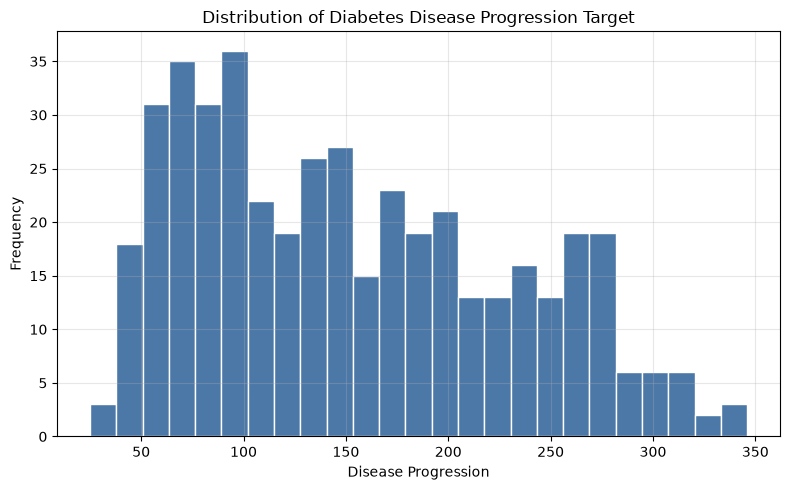

In [6]:
plt.figure(figsize=(8, 5))
plt.hist(y, bins=25, color="#4c78a8", edgecolor="white")
plt.title("Distribution of Diabetes Disease Progression Target")
plt.xlabel("Disease Progression")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("screenshots/04_target_distribution.png", dpi=150)
plt.show()


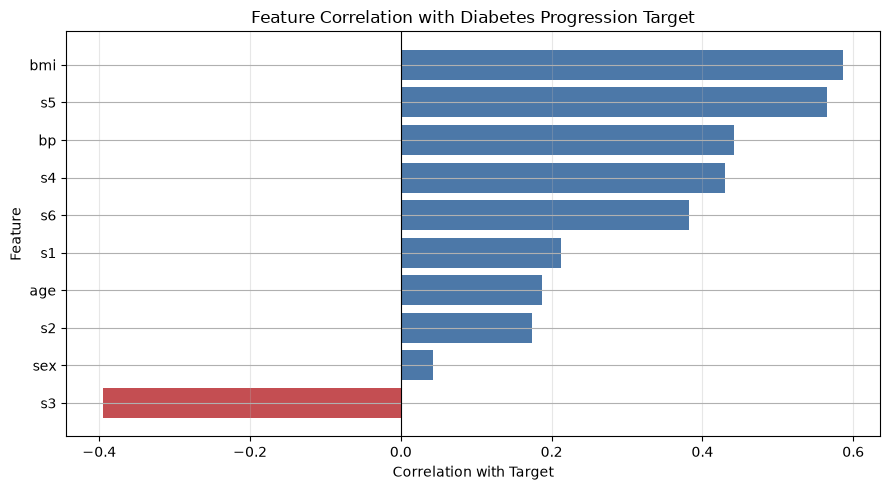

,Correlation with Target
s3,-0.3948
sex,0.0431
s2,0.1741
age,0.1879
s1,0.2120
s6,0.3825
s4,0.4305
bp,0.4415
s5,0.5659
bmi,0.5865


In [7]:
feature_target_correlation = df.corr(numeric_only=True)["target"].drop("target").sort_values()

plt.figure(figsize=(9, 5))
colors = ["#c44e52" if value < 0 else "#4c78a8" for value in feature_target_correlation]
plt.barh(feature_target_correlation.index, feature_target_correlation.values, color=colors)
plt.title("Feature Correlation with Diabetes Progression Target")
plt.xlabel("Correlation with Target")
plt.ylabel("Feature")
plt.axvline(0, color="black", linewidth=0.8)
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("screenshots/05_feature_target_correlation.png", dpi=150)
plt.show()

feature_target_correlation.round(4).to_frame(name="Correlation with Target")


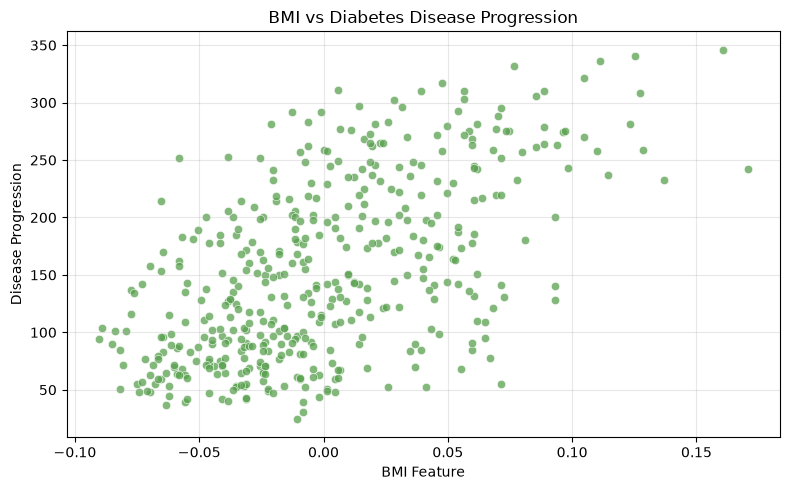

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(df["bmi"], y, alpha=0.75, color="#59a14f", edgecolor="white", linewidth=0.5)
plt.title("BMI vs Diabetes Disease Progression")
plt.xlabel("BMI Feature")
plt.ylabel("Disease Progression")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("screenshots/06_bmi_vs_target.png", dpi=150)
plt.show()


The target distribution helps us see the spread of disease progression values. The correlation chart helps identify useful predictors. The `bmi` feature is used for Simple Linear Regression because it has a clear relationship with the target and is easy to interpret visually.


## Train/Test Split

Training data is used to fit the model. Testing data is kept separate so we can evaluate how well the model performs on unseen data. The same train/test split is used across models for fair comparison.


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

split_summary = pd.DataFrame({
    "Object": ["X_train", "X_test", "y_train", "y_test"],
    "Shape": [X_train.shape, X_test.shape, y_train.shape, y_test.shape]
})
split_summary


,Object,Shape
0,X_train,"(353, 10)"
1,X_test,"(89, 10)"
2,y_train,"(353,)"
3,y_test,"(89,)"


## Step 2: Simple Linear Regression

Simple Linear Regression uses one independent variable to predict the target. Here, `bmi` is used as a single-feature baseline. This helps show what a simple model can and cannot capture.


In [10]:
results = []

simple_feature = "bmi"
X_simple = X[[simple_feature]]

X_simple_train, X_simple_test, y_simple_train, y_simple_test = train_test_split(
    X_simple,
    y,
    test_size=0.2,
    random_state=42
)

simple_model = LinearRegression()
simple_model.fit(X_simple_train, y_simple_train)

simple_train_predictions = simple_model.predict(X_simple_train)
simple_test_predictions = simple_model.predict(X_simple_test)

simple_result = evaluate_model(
    "Simple Linear Regression",
    y_simple_train,
    simple_train_predictions,
    y_simple_test,
    simple_test_predictions
)
results.append(simple_result)

simple_details = pd.DataFrame({
    "Metric": ["Feature", "Coefficient", "Intercept"],
    "Value": [simple_feature, simple_model.coef_[0], simple_model.intercept_]
})

display(simple_details)
display(pd.DataFrame([simple_result]).round(4))


,Metric,Value
0,Feature,bmi
1,Coefficient,998.577689
2,Intercept,152.003354


,Model,Train MAE,Test MAE,Train MSE,Test MSE,Train RMSE,Test RMSE,Train R2,Test R2
0,Simple Linear Regression,51.3797,52.26,3854.1127,4061.8259,62.0815,63.7325,0.3657,0.2334


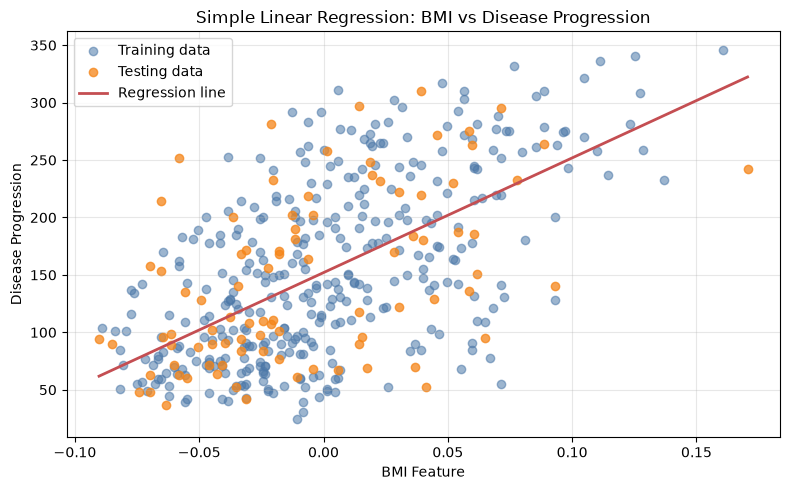

In [11]:
plt.figure(figsize=(8, 5))
plt.scatter(X_simple_train[simple_feature], y_simple_train, alpha=0.55, color="#4c78a8", label="Training data")
plt.scatter(X_simple_test[simple_feature], y_simple_test, alpha=0.75, color="#f58518", label="Testing data")

x_line = np.linspace(X_simple[simple_feature].min(), X_simple[simple_feature].max(), 100).reshape(-1, 1)
y_line = simple_model.predict(pd.DataFrame(x_line, columns=[simple_feature]))
plt.plot(x_line, y_line, color="#c44e52", linewidth=2, label="Regression line")

plt.title("Simple Linear Regression: BMI vs Disease Progression")
plt.xlabel("BMI Feature")
plt.ylabel("Disease Progression")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("screenshots/08_simple_linear_regression_line.png", dpi=150)
plt.show()


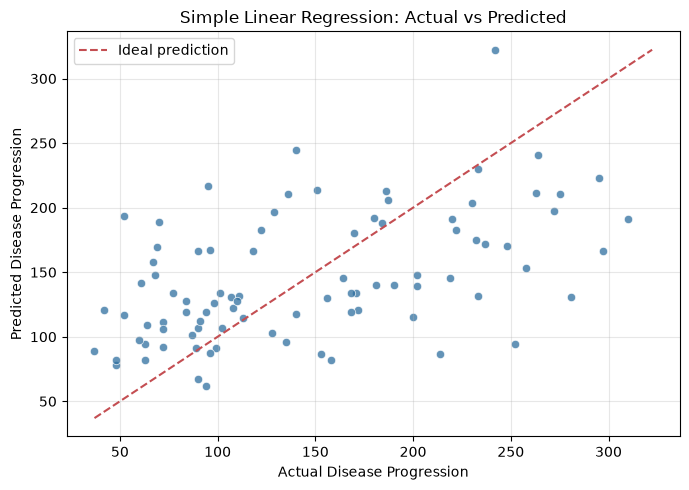

In [12]:
plot_actual_vs_predicted(
    y_simple_test,
    simple_test_predictions,
    "Simple Linear Regression: Actual vs Predicted",
    "screenshots/09_simple_actual_vs_predicted.png"
)


The regression line shows the general trend between `bmi` and disease progression. Because this model uses only one feature, it is easy to interpret, but it may underfit because it ignores the other available health measurements.


## Step 3: Multiple Linear Regression

Multiple Linear Regression uses all 10 features to predict disease progression. A pipeline with `StandardScaler` keeps preprocessing and modeling together, which makes the workflow easier to repeat and compare.


In [13]:
multiple_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

multiple_model.fit(X_train, y_train)
multiple_train_predictions = multiple_model.predict(X_train)
multiple_test_predictions = multiple_model.predict(X_test)

multiple_result = evaluate_model(
    "Multiple Linear Regression",
    y_train,
    multiple_train_predictions,
    y_test,
    multiple_test_predictions
)
results.append(multiple_result)

multiple_coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": multiple_model.named_steps["model"].coef_
})
multiple_coefficients["Absolute Coefficient"] = multiple_coefficients["Coefficient"].abs()
multiple_coefficients = multiple_coefficients.sort_values("Absolute Coefficient", ascending=False)

display(pd.DataFrame([multiple_result]).round(4))
display(multiple_coefficients.round(4))


,Model,Train MAE,Test MAE,Train MSE,Test MSE,Train RMSE,Test RMSE,Train R2,Test R2
0,Multiple Linear Regression,43.4835,42.7941,2868.5497,2900.1936,53.5588,53.8534,0.5279,0.4526


,Feature,Coefficient,Absolute Coefficient
4,s1,-44.4489,44.4489
8,s5,35.1612,35.1612
2,bmi,25.6071,25.6071
5,s2,24.6410,24.6410
3,bp,16.8289,16.8289
7,s4,13.1388,13.1388
1,sex,-11.5118,11.5118
6,s3,7.6770,7.6770
9,s6,2.3514,2.3514
0,age,1.7538,1.7538


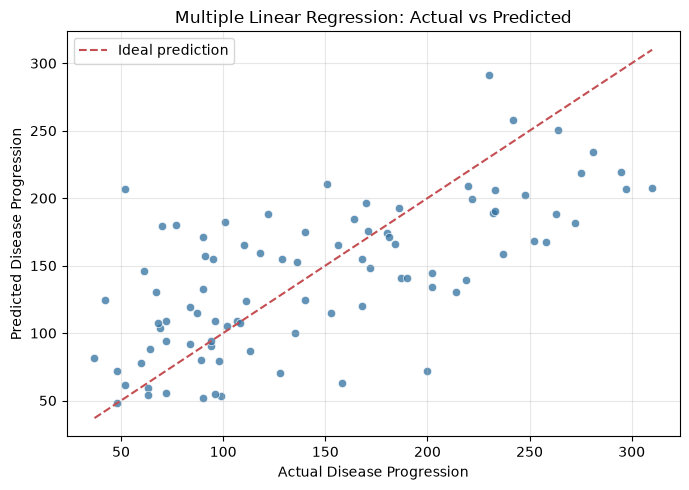

In [14]:
plot_actual_vs_predicted(
    y_test,
    multiple_test_predictions,
    "Multiple Linear Regression: Actual vs Predicted",
    "screenshots/10_multiple_actual_vs_predicted.png"
)


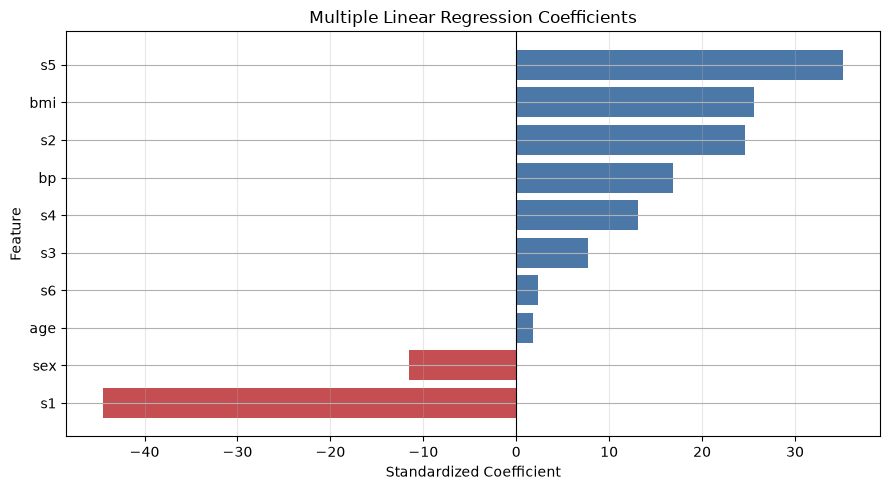

In [15]:
plt.figure(figsize=(9, 5))
coefficient_plot_data = multiple_coefficients.sort_values("Coefficient")
colors = ["#c44e52" if value < 0 else "#4c78a8" for value in coefficient_plot_data["Coefficient"]]
plt.barh(coefficient_plot_data["Feature"], coefficient_plot_data["Coefficient"], color=colors)
plt.title("Multiple Linear Regression Coefficients")
plt.xlabel("Standardized Coefficient")
plt.ylabel("Feature")
plt.axvline(0, color="black", linewidth=0.8)
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("screenshots/11_multiple_coefficients.png", dpi=150)
plt.show()


Multiple Regression uses more information than Simple Linear Regression, so it can capture more relationships in the dataset. The coefficient chart helps show which features have larger positive or negative effects after scaling.


## Step 4: Polynomial Regression

Polynomial Regression creates nonlinear feature transformations. In this section, the model still uses only `bmi` so the curved relationships can be visualized clearly. Degrees 2, 3, and 4 are compared to show how increasing complexity affects performance.


In [16]:
degrees = [2, 3, 4]
polynomial_results = []
polynomial_models = {}

for degree in degrees:
    polynomial_model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ])
    
    polynomial_model.fit(X_simple_train, y_simple_train)
    polynomial_train_predictions = polynomial_model.predict(X_simple_train)
    polynomial_test_predictions = polynomial_model.predict(X_simple_test)
    
    polynomial_result = evaluate_model(
        f"Polynomial Regression degree {degree}",
        y_simple_train,
        polynomial_train_predictions,
        y_simple_test,
        polynomial_test_predictions
    )
    polynomial_result["Degree"] = degree
    polynomial_results.append(polynomial_result)
    results.append({key: value for key, value in polynomial_result.items() if key != "Degree"})
    polynomial_models[degree] = polynomial_model

polynomial_results_df = pd.DataFrame(polynomial_results).round(4)
polynomial_results_df


,Model,Train MAE,Test MAE,Train MSE,Test MSE,Train RMSE,Test RMSE,Train R2,Test R2,Degree
0,Polynomial Regression degree 2,51.3266,52.3839,3849.3331,4085.0255,62.0430,63.9142,0.3665,0.2290,2
1,Polynomial Regression degree 3,51.2801,52.1814,3848.4472,4064.4434,62.0359,63.7530,0.3667,0.2329,3
2,Polynomial Regression degree 4,51.1003,52.3763,3831.0572,4226.1449,61.8955,65.0088,0.3695,0.2023,4


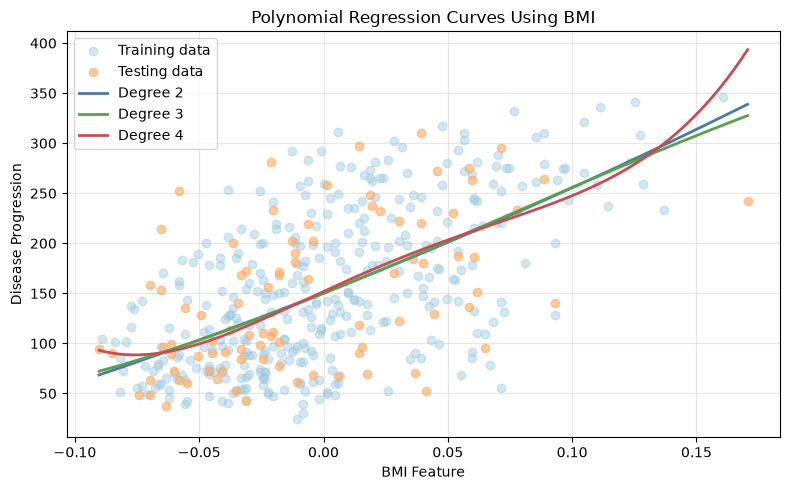

In [17]:
plt.figure(figsize=(8, 5))
plt.scatter(X_simple_train[simple_feature], y_simple_train, alpha=0.45, color="#9ecae1", label="Training data")
plt.scatter(X_simple_test[simple_feature], y_simple_test, alpha=0.65, color="#fdae6b", label="Testing data")

x_grid = np.linspace(X_simple[simple_feature].min(), X_simple[simple_feature].max(), 200)
x_grid_df = pd.DataFrame({simple_feature: x_grid})
curve_colors = {2: "#4c78a8", 3: "#59a14f", 4: "#c44e52"}

for degree in degrees:
    y_curve = polynomial_models[degree].predict(x_grid_df)
    plt.plot(x_grid, y_curve, linewidth=2, color=curve_colors[degree], label=f"Degree {degree}")

plt.title("Polynomial Regression Curves Using BMI")
plt.xlabel("BMI Feature")
plt.ylabel("Disease Progression")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("screenshots/12_polynomial_regression_curves.png", dpi=150)
plt.show()


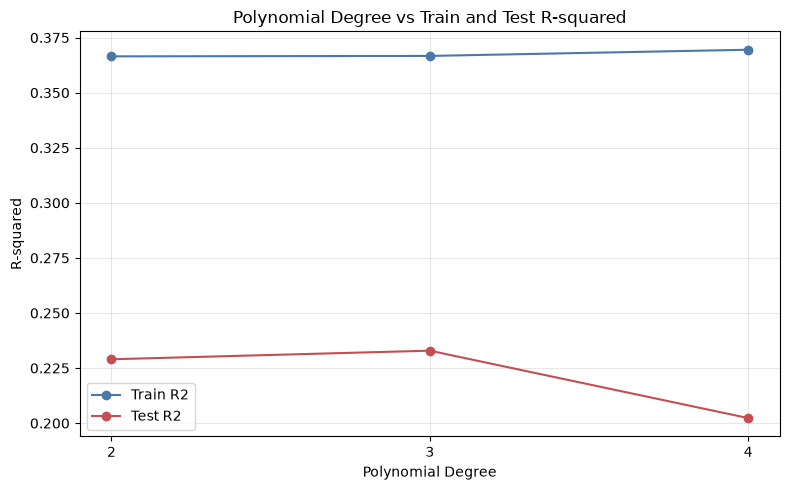

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(polynomial_results_df["Degree"], polynomial_results_df["Train R2"], marker="o", label="Train R2", color="#4c78a8")
plt.plot(polynomial_results_df["Degree"], polynomial_results_df["Test R2"], marker="o", label="Test R2", color="#c44e52")
plt.title("Polynomial Degree vs Train and Test R-squared")
plt.xlabel("Polynomial Degree")
plt.ylabel("R-squared")
plt.xticks(degrees)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("screenshots/13_polynomial_degree_r2.png", dpi=150)
plt.show()


Polynomial features allow nonlinear curves. If training R-squared improves while testing R-squared does not improve, that can suggest overfitting. The actual Train R2 and Test R2 values above should be used when writing the final interpretation.


## Step 5: Regularization with Ridge and Lasso Regression

Ridge Regression uses L2 regularization and shrinks coefficients without usually forcing them to zero. Lasso Regression uses L1 regularization and can set some coefficients to zero. The alpha value controls regularization strength, and larger alpha values usually increase coefficient shrinkage.


In [19]:
alpha_values = [0.01, 0.1, 1, 10, 100]

ridge_results = []
ridge_models = {}

for alpha in alpha_values:
    ridge_model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=alpha))
    ])
    
    ridge_model.fit(X_train, y_train)
    ridge_train_predictions = ridge_model.predict(X_train)
    ridge_test_predictions = ridge_model.predict(X_test)
    
    ridge_result = evaluate_model(
        f"Ridge Regression alpha {alpha}",
        y_train,
        ridge_train_predictions,
        y_test,
        ridge_test_predictions
    )
    ridge_coefficients = ridge_model.named_steps["model"].coef_
    ridge_result["Alpha"] = alpha
    ridge_result["Nonzero Coefficients"] = np.sum(np.abs(ridge_coefficients) > 1e-6)
    ridge_results.append(ridge_result)
    ridge_models[alpha] = ridge_model

ridge_results_df = pd.DataFrame(ridge_results).sort_values("Test RMSE").reset_index(drop=True)
ridge_results_df.round(4)


,Model,Train MAE,Test MAE,Train MSE,Test MSE,Train RMSE,Test RMSE,Train R2,Test R2,Alpha,Nonzero Coefficients
0,Ridge Regression alpha 100,44.5605,43.2507,2966.4727,2858.2243,54.4653,53.4624,0.5118,0.4605,100.00,10
1,Ridge Regression alpha 10,43.6385,42.8568,2887.5157,2875.7787,53.7356,53.6263,0.5248,0.4572,10.00,10
2,Ridge Regression alpha 1,43.4947,42.8120,2870.2961,2892.0146,53.5751,53.7775,0.5276,0.4541,1.00,10
3,Ridge Regression alpha 0.1,43.4837,42.7962,2868.5777,2899.0546,53.5591,53.8429,0.5279,0.4528,0.10,10
4,Ridge Regression alpha 0.01,43.4835,42.7942,2868.5500,2900.0751,53.5588,53.8523,0.5279,0.4526,0.01,10


In [20]:
lasso_results = []
lasso_models = {}

for alpha in alpha_values:
    lasso_model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=alpha, max_iter=10000, random_state=42))
    ])
    
    lasso_model.fit(X_train, y_train)
    lasso_train_predictions = lasso_model.predict(X_train)
    lasso_test_predictions = lasso_model.predict(X_test)
    
    lasso_result = evaluate_model(
        f"Lasso Regression alpha {alpha}",
        y_train,
        lasso_train_predictions,
        y_test,
        lasso_test_predictions
    )
    lasso_coefficients = lasso_model.named_steps["model"].coef_
    lasso_result["Alpha"] = alpha
    lasso_result["Nonzero Coefficients"] = np.sum(np.abs(lasso_coefficients) > 1e-6)
    lasso_results.append(lasso_result)
    lasso_models[alpha] = lasso_model

lasso_results_df = pd.DataFrame(lasso_results).sort_values("Test RMSE").reset_index(drop=True)
lasso_results_df.round(4)


,Model,Train MAE,Test MAE,Train MSE,Test MSE,Train RMSE,Test RMSE,Train R2,Test R2,Alpha,Nonzero Coefficients
0,Lasso Regression alpha 1,43.8391,42.8030,2901.2161,2824.5681,53.8629,53.1467,0.5225,0.4669,1.00,9
1,Lasso Regression alpha 0.1,43.5157,42.8052,2872.7909,2884.6243,53.5984,53.7087,0.5272,0.4555,0.10,10
2,Lasso Regression alpha 0.01,43.4841,42.7950,2868.5922,2898.3680,53.5592,53.8365,0.5279,0.4529,0.01,10
3,Lasso Regression alpha 10,47.6455,44.7646,3250.4038,2933.8347,57.0123,54.1649,0.4651,0.4463,10.00,4
4,Lasso Regression alpha 100,66.4482,64.0065,6076.3980,5361.5335,77.9513,73.2225,0.0000,-0.0120,100.00,0


In [21]:
best_ridge = ridge_results_df.iloc[0]
best_lasso = lasso_results_df.iloc[0]
best_ridge_alpha = best_ridge["Alpha"]
best_lasso_alpha = best_lasso["Alpha"]

best_ridge_model = ridge_models[best_ridge_alpha]
best_lasso_model = lasso_models[best_lasso_alpha]

best_ridge_train_predictions = best_ridge_model.predict(X_train)
best_ridge_test_predictions = best_ridge_model.predict(X_test)
best_lasso_train_predictions = best_lasso_model.predict(X_train)
best_lasso_test_predictions = best_lasso_model.predict(X_test)

best_ridge_result = evaluate_model(
    "Best Ridge Regression",
    y_train,
    best_ridge_train_predictions,
    y_test,
    best_ridge_test_predictions
)
best_ridge_result["Alpha"] = best_ridge_alpha

best_lasso_result = evaluate_model(
    "Best Lasso Regression",
    y_train,
    best_lasso_train_predictions,
    y_test,
    best_lasso_test_predictions
)
best_lasso_result["Alpha"] = best_lasso_alpha

results.append(best_ridge_result)
results.append(best_lasso_result)

best_regularized_summary = pd.DataFrame([best_ridge_result, best_lasso_result]).round(4)
best_regularized_summary


,Model,Train MAE,Test MAE,Train MSE,Test MSE,Train RMSE,Test RMSE,Train R2,Test R2,Alpha
0,Best Ridge Regression,44.5605,43.2507,2966.4727,2858.2243,54.4653,53.4624,0.5118,0.4605,100.0
1,Best Lasso Regression,43.8391,42.8030,2901.2161,2824.5681,53.8629,53.1467,0.5225,0.4669,1.0


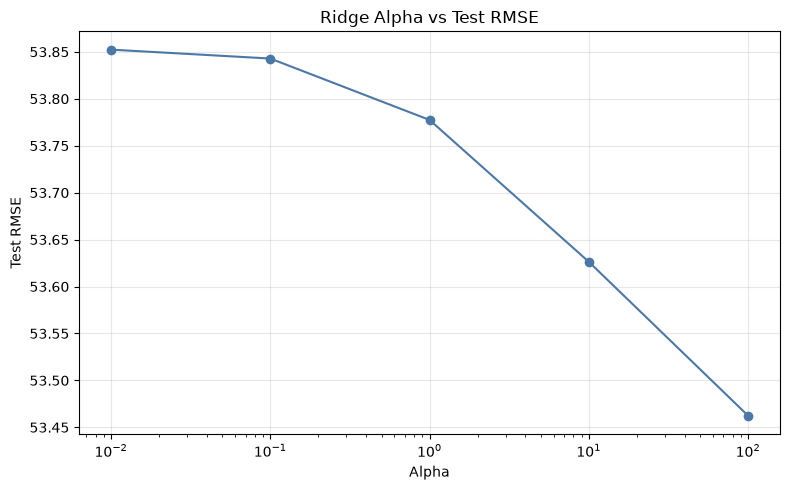

In [22]:
plt.figure(figsize=(8, 5))
ridge_alpha_plot = pd.DataFrame(ridge_results).sort_values("Alpha")
plt.plot(ridge_alpha_plot["Alpha"], ridge_alpha_plot["Test RMSE"], marker="o", color="#4c78a8")
plt.xscale("log")
plt.title("Ridge Alpha vs Test RMSE")
plt.xlabel("Alpha")
plt.ylabel("Test RMSE")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("screenshots/14_ridge_alpha_rmse.png", dpi=150)
plt.show()


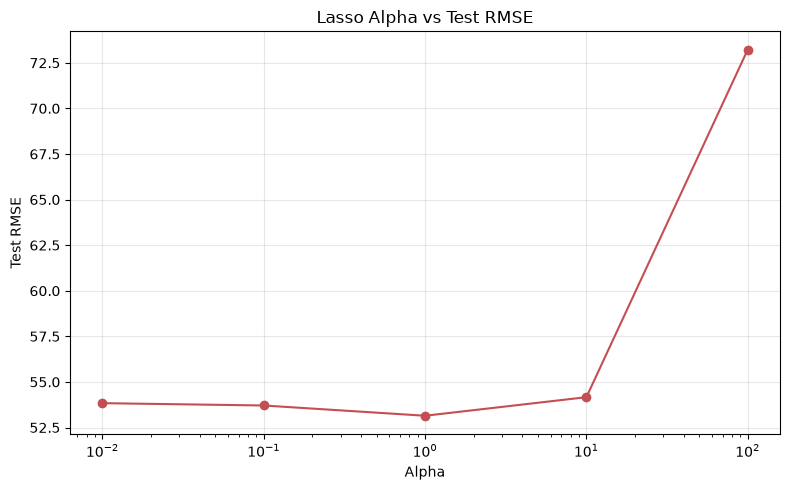

In [23]:
plt.figure(figsize=(8, 5))
lasso_alpha_plot = pd.DataFrame(lasso_results).sort_values("Alpha")
plt.plot(lasso_alpha_plot["Alpha"], lasso_alpha_plot["Test RMSE"], marker="o", color="#c44e52")
plt.xscale("log")
plt.title("Lasso Alpha vs Test RMSE")
plt.xlabel("Alpha")
plt.ylabel("Test RMSE")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("screenshots/15_lasso_alpha_rmse.png", dpi=150)
plt.show()


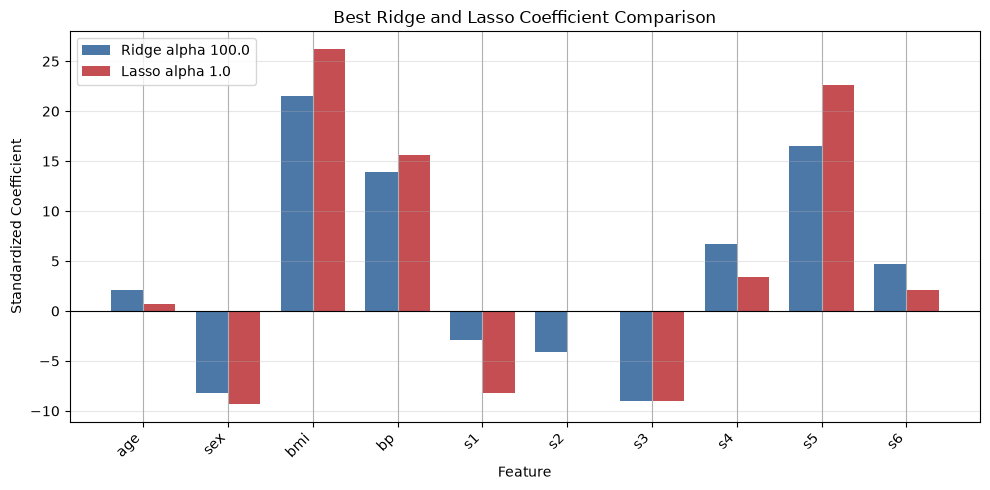

,Feature,Best Ridge Coefficient,Best Lasso Coefficient
0,age,2.0938,0.6870
1,sex,-8.1681,-9.2975
2,bmi,21.5619,26.2192
3,bp,13.9269,15.6573
4,s1,-2.8983,-8.2282
5,s2,-4.0872,-0.0000
6,s3,-9.0593,-9.0241
7,s4,6.6839,3.4209
8,s5,16.4772,22.6365
9,s6,4.6888,2.0986


In [24]:
ridge_lasso_coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Best Ridge Coefficient": best_ridge_model.named_steps["model"].coef_,
    "Best Lasso Coefficient": best_lasso_model.named_steps["model"].coef_
})

x_positions = np.arange(len(ridge_lasso_coefficients))
bar_width = 0.38

plt.figure(figsize=(10, 5))
plt.bar(x_positions - bar_width / 2, ridge_lasso_coefficients["Best Ridge Coefficient"], width=bar_width, label=f"Ridge alpha {best_ridge_alpha}", color="#4c78a8")
plt.bar(x_positions + bar_width / 2, ridge_lasso_coefficients["Best Lasso Coefficient"], width=bar_width, label=f"Lasso alpha {best_lasso_alpha}", color="#c44e52")
plt.title("Best Ridge and Lasso Coefficient Comparison")
plt.xlabel("Feature")
plt.ylabel("Standardized Coefficient")
plt.xticks(x_positions, ridge_lasso_coefficients["Feature"], rotation=45, ha="right")
plt.axhline(0, color="black", linewidth=0.8)
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("screenshots/16_ridge_lasso_coefficients.png", dpi=150)
plt.show()

ridge_lasso_coefficients.round(4)


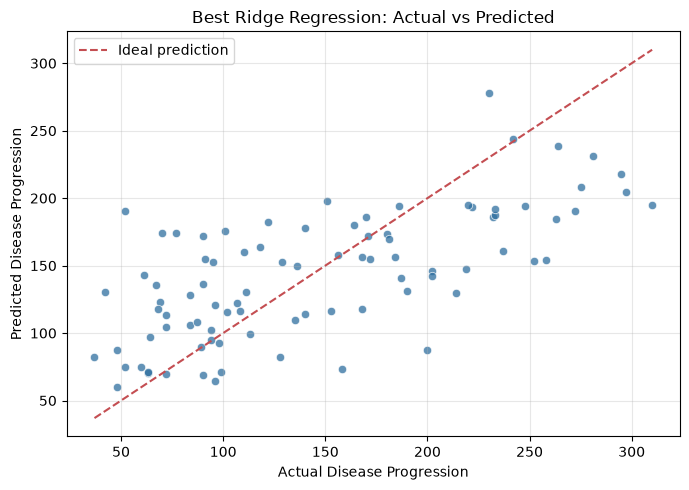

In [25]:
plot_actual_vs_predicted(
    y_test,
    best_ridge_test_predictions,
    "Best Ridge Regression: Actual vs Predicted",
    "screenshots/17_ridge_actual_vs_predicted.png"
)


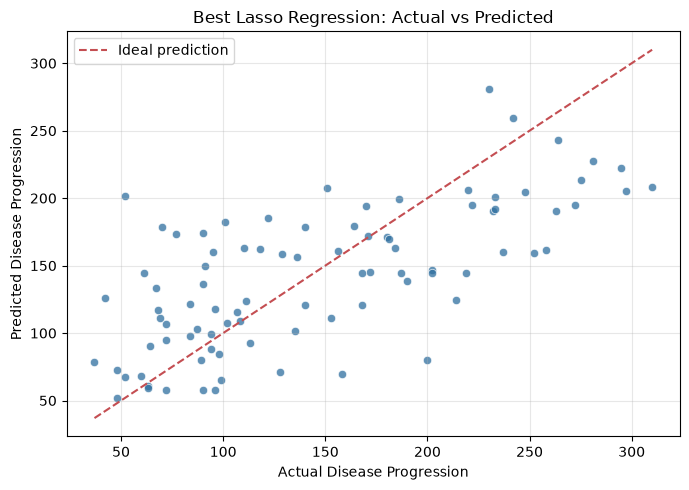

In [26]:
plot_actual_vs_predicted(
    y_test,
    best_lasso_test_predictions,
    "Best Lasso Regression: Actual vs Predicted",
    "screenshots/18_lasso_actual_vs_predicted.png"
)


Ridge and Lasso show how regularization changes model performance and coefficient behavior. Ridge usually keeps all coefficients but makes them smaller. Lasso can reduce some coefficients to zero, which can also support feature selection.


## Cross-Validation

Cross-validation evaluates whether model performance is stable across different splits. This supports the final recommendation because it gives another view beyond one train/test split.


In [27]:
cv_models = {
    "Multiple Linear Regression": multiple_model,
    f"Best Ridge Regression alpha {best_ridge_alpha}": best_ridge_model,
    f"Best Lasso Regression alpha {best_lasso_alpha}": best_lasso_model,
}

cv_results = []
for model_name, model in cv_models.items():
    cv_scores = cross_val_score(
        model,
        X,
        y,
        scoring="neg_root_mean_squared_error",
        cv=5
    )
    cv_rmse_scores = -cv_scores
    cv_results.append({
        "Model": model_name,
        "Mean CV RMSE": cv_rmse_scores.mean(),
        "CV RMSE Std": cv_rmse_scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("Mean CV RMSE").reset_index(drop=True)
cv_results_df.round(4)


,Model,Mean CV RMSE,CV RMSE Std
0,Multiple Linear Regression,54.6918,1.3745
1,Best Lasso Regression alpha 1.0,54.7113,1.0319
2,Best Ridge Regression alpha 100.0,55.1559,1.0318


## Step 6: Model Comparison and Analysis

The final comparison table brings all model results together. Lower Test RMSE is better, and higher Test R2 is better. Train R2 and Test R2 are compared to check whether a model may be overfitting.


In [28]:
results_df = pd.DataFrame(results)
results_df = results_df[[
    "Model",
    "Train MAE",
    "Test MAE",
    "Train MSE",
    "Test MSE",
    "Train RMSE",
    "Test RMSE",
    "Train R2",
    "Test R2"
] + (["Alpha"] if "Alpha" in results_df.columns else [])]

results_df_sorted = results_df.sort_values("Test RMSE").reset_index(drop=True)
results_df_sorted.round(4)


,Model,Train MAE,Test MAE,Train MSE,Test MSE,Train RMSE,Test RMSE,Train R2,Test R2,Alpha
0,Best Lasso Regression,43.8391,42.8030,2901.2161,2824.5681,53.8629,53.1467,0.5225,0.4669,1.0
1,Best Ridge Regression,44.5605,43.2507,2966.4727,2858.2243,54.4653,53.4624,0.5118,0.4605,100.0
2,Multiple Linear Regression,43.4835,42.7941,2868.5497,2900.1936,53.5588,53.8534,0.5279,0.4526,NaN
3,Simple Linear Regression,51.3797,52.2600,3854.1127,4061.8259,62.0815,63.7325,0.3657,0.2334,NaN
4,Polynomial Regression degree 3,51.2801,52.1814,3848.4472,4064.4434,62.0359,63.7530,0.3667,0.2329,NaN
5,Polynomial Regression degree 2,51.3266,52.3839,3849.3331,4085.0255,62.0430,63.9142,0.3665,0.2290,NaN
6,Polynomial Regression degree 4,51.1003,52.3763,3831.0572,4226.1449,61.8955,65.0088,0.3695,0.2023,NaN


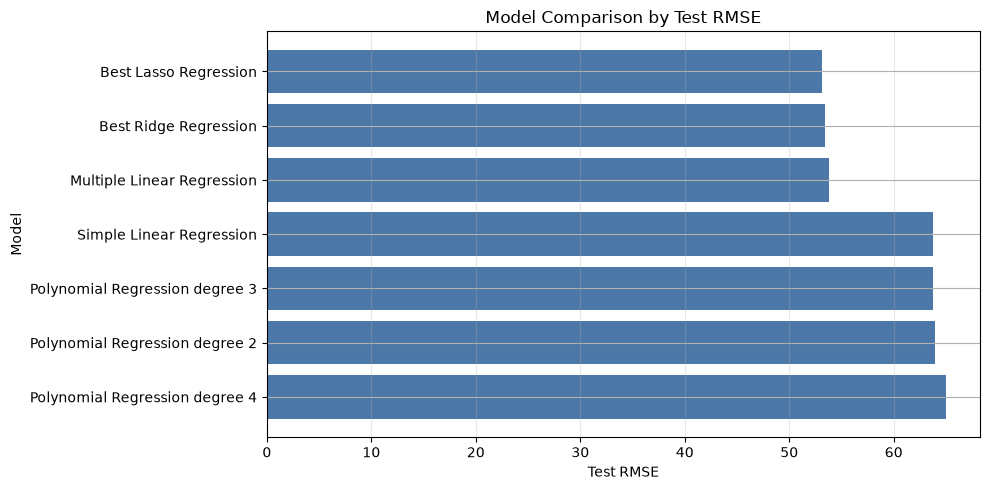

In [29]:
plt.figure(figsize=(10, 5))
rmse_plot_data = results_df_sorted.sort_values("Test RMSE", ascending=False)
plt.barh(rmse_plot_data["Model"], rmse_plot_data["Test RMSE"], color="#4c78a8")
plt.title("Model Comparison by Test RMSE")
plt.xlabel("Test RMSE")
plt.ylabel("Model")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("screenshots/20_model_comparison_rmse.png", dpi=150)
plt.show()


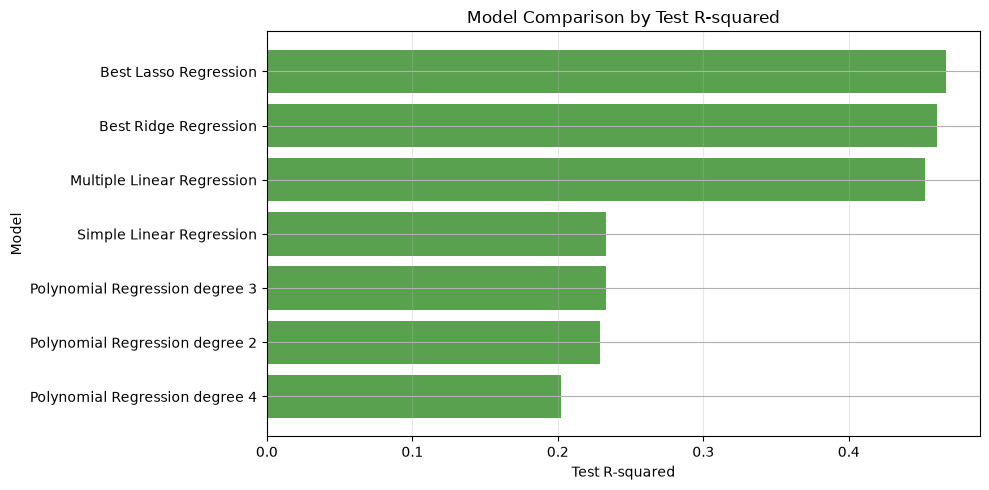

In [30]:
plt.figure(figsize=(10, 5))
r2_plot_data = results_df_sorted.sort_values("Test R2")
plt.barh(r2_plot_data["Model"], r2_plot_data["Test R2"], color="#59a14f")
plt.title("Model Comparison by Test R-squared")
plt.xlabel("Test R-squared")
plt.ylabel("Model")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("screenshots/21_model_comparison_r2.png", dpi=150)
plt.show()


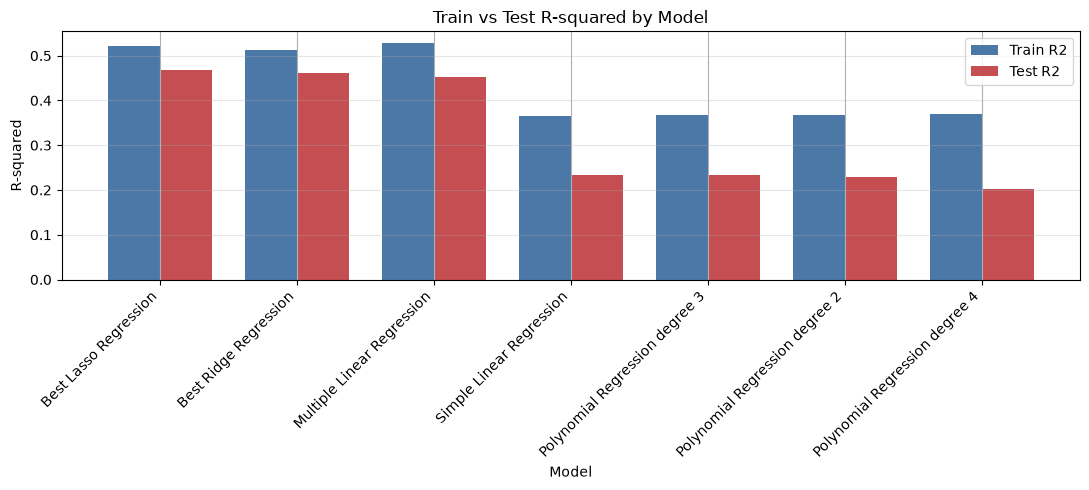

In [31]:
r2_comparison = results_df_sorted[["Model", "Train R2", "Test R2"]].set_index("Model")

plt.figure(figsize=(11, 5))
x_positions = np.arange(len(r2_comparison.index))
bar_width = 0.38
plt.bar(x_positions - bar_width / 2, r2_comparison["Train R2"], width=bar_width, label="Train R2", color="#4c78a8")
plt.bar(x_positions + bar_width / 2, r2_comparison["Test R2"], width=bar_width, label="Test R2", color="#c44e52")
plt.title("Train vs Test R-squared by Model")
plt.xlabel("Model")
plt.ylabel("R-squared")
plt.xticks(x_positions, r2_comparison.index, rotation=45, ha="right")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("screenshots/22_train_vs_test_r2.png", dpi=150)
plt.show()


In [32]:
best_rmse_row = results_df_sorted.iloc[0]
best_r2_row = results_df.sort_values("Test R2", ascending=False).iloc[0]

final_summary = pd.DataFrame({
    "Question": [
        "Best model by Test RMSE",
        "Best model by Test R2",
        "Best Ridge alpha",
        "Best Lasso alpha"
    ],
    "Answer": [
        f"{best_rmse_row['Model']} with Test RMSE {best_rmse_row['Test RMSE']:.4f}",
        f"{best_r2_row['Model']} with Test R2 {best_r2_row['Test R2']:.4f}",
        best_ridge_alpha,
        best_lasso_alpha
    ]
})
final_summary


,Question,Answer
0,Best model by Test RMSE,Best Lasso Regression with Test RMSE 53.1467
1,Best model by Test R2,Best Lasso Regression with Test R2 0.4669
2,Best Ridge alpha,100.0
3,Best Lasso alpha,1.0


## Final Recommendation and Key Takeaways

For this dataset and train/test split, **Lasso Regression with alpha 1** produced the best held-out performance. It had the lowest Test RMSE of **53.1467** and the highest Test R-squared of **0.4669**. The best Ridge model used alpha 100 and produced Test RMSE **53.4624** and Test R-squared **0.4605**.

The five-fold cross-validation results were close. Multiple Linear Regression had the lowest mean CV RMSE at **54.6918** with a standard deviation of **1.3745**. Lasso with alpha 1 had mean CV RMSE **54.7113** with a lower standard deviation of **1.0319**. This suggests that the Lasso result was competitive and reasonably stable across folds, although Multiple Linear Regression had the slightly lower mean CV error.

Simple Linear Regression using only `bmi` was a useful baseline, but its Test RMSE of **63.7325** and Test R-squared of **0.2334** were weaker than the multiple-feature models. Polynomial Regression did not improve performance in this run. Degree 4 slightly increased Train R-squared to **0.3695**, while Test R-squared fell to **0.2023**, indicating that the extra flexibility did not generalize well and showed signs of overfitting.

Ridge retained all 10 coefficients across the tested alpha values. Increasing Ridge alpha strengthened coefficient shrinkage and slightly improved test performance, with alpha 100 performing best. Lasso increasingly reduced coefficients to zero as alpha increased. Alpha 1 retained 9 nonzero coefficients and performed best, while alpha 100 reduced every coefficient to zero and produced poor test performance, showing the effect of excessive regularization.

The actual-vs-predicted plot for the best Lasso model follows the overall positive trend, but several observations remain far from the ideal prediction line, especially near the target extremes. This is consistent with its moderate Test R-squared and indicates that important variation remains unexplained.

**Recommendation:** Based on the test metrics, cross-validation results, and actual-vs-predicted plots, I would select **Lasso Regression with alpha 1** as the deployment candidate for this dataset and split. It combined the strongest test performance, cross-validation performance close to the best mean result, lower cross-validation variation, and modest feature selection. This conclusion applies to this run and does not establish that Lasso will always be best. Additional validation and domain review would be required before real clinical use.
